## Transformer Types

**Encoder-only: reads the whole input at once and builds contextual representations using bidirectional attention. Good for understanding tasks like classification, tagging, and search. (aka: understand text)**

Decoder-only: reads tokens left-to-right with a causal mask, so each token sees only earlier tokens. Good for generation tasks like next-word prediction and chat. (aka: generate text)

Encoder-decoder: the encoder first understands the input, then the decoder generates output token by token while attending to the encoder output. Good for input-to-output tasks like translation and summarization. (aka: transform one text into another)

# 6. Forward and Backward in an Encoder-Only Transformer

This notebook demonstrates that an encoder-only transformer is still a neural network, so it supports both a `forward()` pass and a `backward()` pass during training.

We will build each class separately for learning purposes and then run a tiny sequence classification training example.

In [92]:
# importing necessary Python libraries
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

# try argument to check whether matplotlib.pyplot is installed and imported
try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ImportError:
    plt = None
    HAS_MATPLOTLIB = False

# defining manual_seed to ensure reproducability in 'randomness'
#   any seed number will work as well. 
#   '42' does not bring any special or advantages but it weell known to be used
torch.manual_seed(42)

#define pool_logic here
pool_logic = "token-wise"

## Step 1: Token and Positional Embedding

An encoder-only transformer first converts token ids into vectors. We also add positional embeddings so the model knows the order of tokens in the sequence.

In [93]:
# Defining Word Embedding class
#   to process token representation (token + position)
class TokenAndPositionEmbedding(nn.Module):
    # initializing..
    # taking argument
    #   vocab_size: how much unique words represented in token (for vectorized token)
    #   d_model: dimension model (how many numbers inside per token)
    #   max_seq_len: define the maximum number position of seq_len
    def __init__(self, vocab_size, d_model, max_seq_len):
        # inhering the functions and properties from Python NN libraries
        super().__init__()
        # initializing vectorized token and position embedding
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        # Add 1 to max_seq_len to accommodate the [CLS] token
        self.position_embedding = nn.Embedding(max_seq_len + 1, d_model)
        # initializing [CLS] token as a learnable parameter
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        batch_size, seq_len = x.shape

        # Convert token ids into dense vectors
        token_vectors = self.token_embedding(x)

        # if pool_logic is "CLS" this will be used to
        #   prepare the the token with [CLS] tag
        if(pool_logic == "cls"):
            # Prepend [CLS] token to the token vectors
            # cls_tokens shape: (batch_size, 1, d_model)
            cls_tokens = self.cls_token.expand(batch_size, -1, -1)
            token_vectors = torch.cat((cls_tokens, token_vectors), dim=1)

            # Update seq_len because we added the [CLS] token
            seq_len += 1

        # Create position ids like [0, 1, 2, ..., seq_len-1]
        #   and store as the same location as x
        positions = torch.arange(seq_len, device=x.device)
        position_vectors = self.position_embedding(positions)

        # Broadcasting merge/adds position information to every sequence in the batch
        #   pass the combined token_vectors + position_vectors into next tasks..
        return token_vectors + position_vectors

## Step 2: Multi-Head Attention (No Masking)

Unlike the decoder, the encoder uses **bidirectional** attention. Each token can attend to *all* other tokens in the sequence, both before and after it. There is no causal mask here.
- **Encoder only transformer**
    - Tokens can interact before and after sequence
    - No causal mask is needed
- Decoder only transfromer
    - Token can interact before sequence only
    - Causal mask is needed to mask/filter the after sequence tokens

In [94]:
# Defining Multi-Head Attention (Attention WITHOUT mask) class
#   to proces vectorized token to talk with one another with vector space (Q,K,V)
#   within multiple focus (heads) and 
#   combine back together in vector space (O)
class MultiHeadAttention(nn.Module):
    # initializing
    def __init__(self, d_model, num_heads):
        # inheriting Python Pytorch NN libraries
        super().__init__()
        assert d_model % num_heads == 0, 'd_model must be divisible by num_heads'

        self.d_model = d_model
        self.num_heads = num_heads
        # use floor division operation (//) to get rounded number of head_dim 
        #   (aka d_k)
        self.head_dim = d_model // num_heads

        # initialize linear projection space for vectorized token to talk one another
        #   for Q, K, V and O
        #   with dimension (d_model, d_model) 
        self.query = nn.Linear(d_model, d_model)
        self.key = nn.Linear(d_model, d_model)
        self.value = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        batch_size, seq_len, d_model = x.shape

        # Project the input into query, key, and value tensors
        #   into Q, K, V vector space
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        # Split the model dimension into multiple heads
        #   and transpose the dimension between (dim1 and dim2)
        q = q.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        # Vectorized token talks one another takes place..
        # Compute raw attention scores independently for each head (QK^T/ sqrt(head_dim))
        scores = q @ k.transpose(-2, -1) / math.sqrt(self.head_dim)

        # NO CAUSAL MASK IN ENCODER
        # Every token can look at every other token (bidirectional context)

        # Softmax turns scores into attention weights for each head
        #   softmax() = attention_score -> attention_weight
        #      dim=-1 refers to the innermost dimension (dim_head)
        attention_weights = F.softmax(scores, dim=-1)

        # Weighted sum of value vectors produces context-aware representations per head (QK^T/sqrt(dim_head))V
        #   weighted_sum = attention_weight @ v 
        #   (similar to formula: weighted_sum = wn.in + b in NN)
        attended = attention_weights @ v

        # Merge all heads back into one d_model-sized representation
        # Reshape from (batch_size, seq_len, num_heads, head_dim) ->
        #               (batch_size, seq_len, d_model)
        attended = attended.transpose(1, 2).contiguous().view(batch_size, seq_len, d_model)

        # execute merged/combined multi-head attention vectorized from Q,K and V
        #   into linear projection space
        #   and pass into next tasks..
        return self.out(attended)

## Step 3: Feed-Forward Network

After attention, each token representation goes through a small neural network. This helps the model transform features at each position independently.

In [95]:
# Defining Feed Forward Network class
#   to proces the updated individual vectorized tokens
#   into feedForward neural network to
#   process transform the updated vectorized tokens based on given context    
class FeedForward(nn.Module):
    # initializing..
    def __init__(self, d_model, d_ff):
        # inheriting Python PyTorch NN libraries
        super().__init__()

        # create one var as runs in sequence
        #   linear() projection space as linear1
        #   run through activation function
        #   linear() proejction space as linear2
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            # the dimension initialized as transposed for matmul()
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        # This is the position-wise MLP used after attention
        #   This is similar like MLP in NN
        return self.net(x)

## Step 4: Encoder Block

An encoder block combines multi-head attention (no mask), dropout, a feed-forward network, residual connections, and layer normalization.

The dropout layer randomly removes some activations during training, which helps reduce overfitting and makes the model more robust.

In [96]:
# Defining EncoderBlock class
#   integrate multiheadattention(), feedforward()
#   with addition of:
#       - dropout (regularization and ensuring generalization, avoid overfitting)
#       - residual connection (adds back x original information)
#       - normalization (ensuring stable training)
class EncoderBlock(nn.Module):
    # initializing
    def __init__(self, d_model, d_ff, num_heads, dropout=0.1):
        # inheriting the Python PyTorch NN libraries
        super().__init__()

        # utilize the created classes above
        # multiheadattention object
        self.attention = MultiHeadAttention(d_model, num_heads)
        # dropout addition object after multiheadattention()
        self.dropout1 = nn.Dropout(dropout)
        # normalize ensuring hidden feature representations is stable for next task..
        self.norm1 = nn.LayerNorm(d_model)

        # feedforward object
        self.feed_forward = FeedForward(d_model, d_ff)
        # dropout addition object after feedforward()
        self.dropout2 = nn.Dropout(dropout)
        # normalize ensuring hidden feature representation is stable for next task..
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        # Dropout regularizes the attention output before the residual add
        #   process multi head attention from (x input)
        #     -> dropout from updated vectorized tokens
        #     -> added back original information of x input (residual)
        #     -> normalize for stable training..
        x = self.norm1(x + self.dropout1(self.attention(x)))

        # new-x in this task (feedforward): 
        #   x after processed 
        #       - multi head attention
        #       - dropout
        #       - added residual
        #       - normalization 

        # Dropout also regularizes the feed-forward output
        #   process multi head attention from (new-x input)
        #     -> dropout from transformed updated vectorized tokens
        #     -> added back original information of new-x input (residual)
        #     -> normalize for stable training..
        x = self.norm2(x + self.dropout2(self.feed_forward(x)))
        return x

## Step 5: Complete Encoder-Only Transformer

Now we combine embeddings, multiple encoder blocks, a final layer normalization, and a final classification head. 

For sequence classification tasks, we typically pool the token representations (e.g., using mean pooling or taking a special `[CLS]` token) to create a single vector representing the entire sequence, and then map it to class logits.

After final normalization:
- **Encoder only transformer**
    - Typically token the token represnetations (mean pooling or taking special '[CLS]' tag token)
    - Later it will projected into classification linear vector space to convert hidden_states into predicted_score [logits]
    - The output [logits] as predicted classification
- Decoder only transfromer
    - Directly projected into output linear vector space to convert hidden_states into prediction_score [logits]
    - The output [logits] as predicted generation (of next token)

In [97]:
# Defining EncoderOnlyTransformer class
#   integrate embedding(), multiple EncoderBlock() layers
#   with addition of:
#       - final layer normalization before pooling
#       - mean pooling across sequence length
#       - output layer (final linear layer maps pooled hidden states to class logits)
class EncoderOnlyTransformer(nn.Module):
    # initializing..
    def __init__(self, vocab_size, d_model, max_seq_len, d_ff, num_heads, num_layers, num_classes, dropout=0.1):
        # inheriting Python PyTorch NN libraries
        super().__init__()

        # creating objects from created classes above..
        # create embedding class
        self.embedding = TokenAndPositionEmbedding(vocab_size, d_model, max_seq_len)
        # create multiple EncoderBlock layers to refine token representations step by step
        self.encoder_blocks = nn.ModuleList([
            EncoderBlock(d_model, d_ff, num_heads, dropout=dropout)
            for _ in range(num_layers)
        ])
        # create final normalization layer before pooling
        self.final_norm = nn.LayerNorm(d_model)
        # create final layer linear porjection space (classifier)
        #   to represent from d_model into num_classes
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # 1. Convert token ids into embeddings
        #   x input -> x's vectorized tokens (token + position)
        x = self.embedding(x)
    
        # 2. Pass embeddings through each encoder block
        #   each block refines the token representation again
        #   x's vectorized tokens (token + position) -> x's transformed updated vectorized token
        #       through hidden layers and states
        for encoder_block in self.encoder_blocks:
            x = encoder_block(x)

        # 3. Normalize the final hidden representation before projection
        x = self.final_norm(x)

        # 4. Pool the representation across the sequence        
        #   There are several ways to get 'x_pooled' from the encoder's output (x) for different tasks:
        if(pool_logic == "mean"):
        #   a) Mean Pooling (Default here): Average all token representations in the sequence.
        #      Good for general sentence classification.
        #      We use mean pooling here over dim=1 (seq_len)
        #      x dimension changes from (batch_size, seq_len, d_model) -> (batch_size, d_model)
            x_pooled = x.mean(dim=1)  # shape: (batch_size, d_model)
        elif(pool_logic == "cls"):
        #   b) [CLS] Token: Use the representation of a special first token (e.g., in BERT).
        #      Requires adding a [CLS] token to the input sequence before the embedding step.
            x_pooled = x[:, 0, :]  # shape: (batch_size, d_model)
        elif(pool_logic == "attention"):        
        #   c) Attention Pooling: Learn a weighted average of tokens based on their importance.
        #      Requires an extra linear layer
            self.attn_pool = nn.Linear(d_model, 1)
            print(f"d_model: {d_model}")
            attn_weights = F.softmax(self.attn_pool(x), dim=1)
            x_pooled = (x * attn_weights).sum(dim=1) # shape: (batch_size, d_model)
        elif(pool_logic == "token-wise"):        
        #   d) Token-wise Logits: No pooling. Keep sequence length to predict a class for every token.
        #      Used for Named Entity Recognition (NER) or Part-of-Speech (POS) tagging.
        #      In token-wise mode we do not prepend [CLS], so keep every token position.
            x_pooled = x

        #   e) Task-specific Heads: Pass x_pooled (or x) into multiple different classifiers
        #      simultaneously (e.g., predicting sentiment and topic at the same time).

        # 5. Convert pooled hidden states into class logits (prediction_score) for sequence classification
        #   x's pooled transformed updated vectorized token -> logits (prediction_score) of classes
        logits = self.classifier(x_pooled)
        return logits

## Step 6: Prepare a Tiny Sequence Classification Example

We will train the model on a tiny batch. The input sequence is a text sequence (tokens), and the target is a single class label per sequence (e.g., 0 for negative, 1 for positive sentiment).

**Trend and Characteristics:**
*   **Class 0:** The sequences are composed entirely of low-number token IDs (e.g., 1, 2, 3, 4, 5, 6, 7). Think of these as words indicating a "Negative" sentiment (e.g., "terrible", "bad").
*   **Class 1:** The sequences start with much higher token IDs (e.g., 10, 11, 12, 13, 14). Even though they might end with a couple of low-number tokens, the prominent presence of the higher IDs at the beginning is the key distinguishing feature. Think of these as words indicating a "Positive" sentiment (e.g., "great", "excellent").

**How the Model Learns:**
During training, the model notices that whenever the input contains vectors representing the higher numbers, the target answer is always `1`. Conversely, when it only contains vectors representing `1 through 7`, the target is `0`. The Multi-Head Attention and Feed-Forward layers adjust their weights to strongly associate the presence of those high-ID tokens with Class 1.

In [98]:
# Set the definition of parameters
vocab_size = 20
d_model = 16
d_ff = 32
num_heads = 4
num_layers = 3
dropout = 0.1
max_seq_len = 6
num_classes = 2 # binary classification

# initialize the combined EncoderOnlyTransformer
model = EncoderOnlyTransformer(
    vocab_size=vocab_size,
    d_model=d_model,
    max_seq_len=max_seq_len,
    d_ff=d_ff,
    num_heads=num_heads,
    num_layers=num_layers,
    num_classes=num_classes,
    dropout=dropout,
)

# define the input
inputs = torch.tensor([
    [1, 2, 3, 4, 5, 6],    # Class 0 Example
    [2, 3, 4, 5, 6, 7],    # Class 0 Example
    [10, 11, 12, 13, 1, 2], # Class 1 Example
    [11, 12, 13, 14, 2, 3]  # Class 1 Example
], dtype=torch.long)

# define the actual output target (ground-truth)
if pool_logic == "token-wise":
    # one label per token position
    # tokens < 10 belong to class 0, tokens >= 10 belong to class 1
    targets = (inputs >= 10).long()
else:
    # one label per sequence
    targets = torch.tensor([0, 0, 1, 1], dtype=torch.long)

# printing out the dimension for input and target
inputs.shape, targets.shape

(torch.Size([4, 6]), torch.Size([4, 6]))

## Step 7: Forward Pass

Calling `model(inputs)` triggers the `forward()` methods of all the classes above. The output shape depends on the pooling logic: `(batch_size, num_classes)` for sequence classification or `(batch_size, seq_len, num_classes)` for token-wise classification.

In [99]:
logits = model(inputs) # <-- also calls model.forward()
# Show the pool logic here..
print(f"Pool logic: {pool_logic}")
print('Logits shape:', logits.shape)
# shows the logits returned by the classifier head for the selected pooling logic
logits

Pool logic: token-wise
Logits shape: torch.Size([4, 6, 2])


tensor([[[ 0.3387, -0.1644],
         [ 0.0605, -1.5311],
         [-0.8147,  0.1720],
         [-0.0861, -0.9752],
         [-0.5800,  1.4369],
         [-0.9482,  0.5883]],

        [[-0.2328, -1.3248],
         [-0.4904, -1.3116],
         [-0.5094,  0.0346],
         [-0.7779,  0.8749],
         [-0.6657, -0.0817],
         [-0.9030,  0.9507]],

        [[-0.8655, -0.2991],
         [-0.0930, -0.2887],
         [-0.2623,  0.5473],
         [-0.5394, -0.2301],
         [-0.2012,  0.1458],
         [-0.4009, -0.7717]],

        [[-0.2238,  0.0645],
         [ 0.6807, -1.2188],
         [-0.9492,  1.2733],
         [-0.4109,  0.4519],
         [-0.3671, -0.8111],
         [-0.8702, -0.2246]]], grad_fn=<ViewBackward0>)

## Step 8: Compute Loss

The model output alone is not enough for training. We compare the sequence logits against the target class labels using cross-entropy loss.

In [100]:
# CrossEntropyLoss compares the predicted class logits with the actual class label
if pool_logic == "token-wise":
    # Flatten batch and sequence together so each token becomes one training example
    loss = F.cross_entropy(
        logits.view(-1, num_classes),
        targets.view(-1)
    )
else:
    loss = F.cross_entropy(
        logits,
        targets
    )

# shows out loss.item() that contains
#   sclar numeric of loss (rate of changes needed between predicted and target)
print('Loss:', loss.item())

Loss: 0.8698158860206604


## Step 9: Backward Pass

Calling `loss.backward()` computes gradients for all learnable parameters via backpropagation.

In [101]:
# reset any stored gradient history..
model.zero_grad()

# Computes gradient for all learnable parameters..
#   Calculate new gradients/slope (weight) based on current loss
#   Similar to backward() in NN
loss.backward()

# These gradients were created by autograd during backpropagation.
print('Gradient shape for classifier weight:', model.classifier.weight.grad.shape)
print('Gradient sample from classifier weight:')
print(model.classifier.weight.grad)

Gradient shape for classifier weight: torch.Size([2, 16])
Gradient sample from classifier weight:
tensor([[ 0.2216, -0.0083,  0.0139, -0.1451, -0.1814, -0.1400,  0.0728,  0.0669,
          0.0834,  0.4353, -0.2159, -0.4220,  0.2113, -0.1282,  0.2255, -0.0899],
        [-0.2216,  0.0083, -0.0139,  0.1451,  0.1814,  0.1400, -0.0728, -0.0669,
         -0.0834, -0.4353,  0.2159,  0.4220, -0.2113,  0.1282, -0.2255,  0.0899]])


## Step 10: One Parameter Update

After `backward()`, an optimizer uses the gradients to update the weights. This is one training step, and repeating this process across many epochs is how the model learns.

In [102]:
# initialize optimizer by using Adam's optimizer
#   and define learning_rate = 0.01
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Use the new gradients/slope (weight) and update into NN
optimizer.step()

print('One optimization step completed.')

One optimization step completed.


## Step 11: Train for Multiple Epochs

To see a learning curve, we train for many epochs and store the loss after each epoch. If the model is learning the pattern to distinguish the two classes of sequences, the loss should go down over time.

In [103]:
# Re-create a fresh model so we can observe learning from the beginning
model = EncoderOnlyTransformer(
    vocab_size=vocab_size,
    d_model=d_model,
    max_seq_len=max_seq_len,
    d_ff=d_ff,
    num_heads=num_heads,
    num_layers=num_layers,
    num_classes=num_classes,
    dropout=dropout,
)

# re-create optimizer object
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# create num_epochs and loss_history to store loss
num_epochs = 100
loss_history = []

# set the model of EncoderOnlyTransformer into training mode..
#   training mode enables:
#       - dropout
#           - activations are randomly dropped during training
#           - helps regularization and generalizability
#           - avoids overfitting
model.train()

# running the training learn in loops based on number of epochs
for epoch in range(num_epochs):
    # reset any stored gradients
    optimizer.zero_grad()

    # Forward pass for the whole batch
    logits = model(inputs)

    # Compare logits with targets using the shape required by the selected pooling logic
    if pool_logic == "token-wise":
        loss = F.cross_entropy(
            logits.view(-1, num_classes),
            targets.view(-1)
        )
    else:
        loss = F.cross_entropy(
            logits,
            targets
        )

    # Backward pass computes gradients for every learnable parameter
    loss.backward()

    # Optimizer updates the weights using those gradients
    optimizer.step()

    # store the history of number of loss 
    #   (rate of change or correctness needed between predicted against target (ground-truth)) 
    loss_history.append(loss.item())

    # show the progress of loss after 20 epochs
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch + 1:3d}/{num_epochs} | Loss: {loss.item():.4f}')

# Show the pool logic here..
print(f"Pool logic: {pool_logic}")
print('Training complete.')
# demonstrate the loss in the first 5 epochs and round up into 4 decimal places
print('First 5 losses:', [round(x, 4) for x in loss_history[:5]])
# demonstrate the loss in the last 5 epochs and round up into 4 decimal places
print('Last 5 losses:', [round(x, 4) for x in loss_history[-5:]])

Epoch  20/100 | Loss: 0.0016
Epoch  40/100 | Loss: 0.0004
Epoch  60/100 | Loss: 0.0003
Epoch  80/100 | Loss: 0.0002
Epoch 100/100 | Loss: 0.0002
Pool logic: token-wise
Training complete.
First 5 losses: [0.5316, 0.4134, 0.2593, 0.1754, 0.0937]
Last 5 losses: [0.0002, 0.0002, 0.0002, 0.0002, 0.0002]


## Step 12: Visualize the Learning Curve

This plot shows how the loss changes across epochs. A downward trend means the encoder-only transformer is learning to classify the sequences correctly.

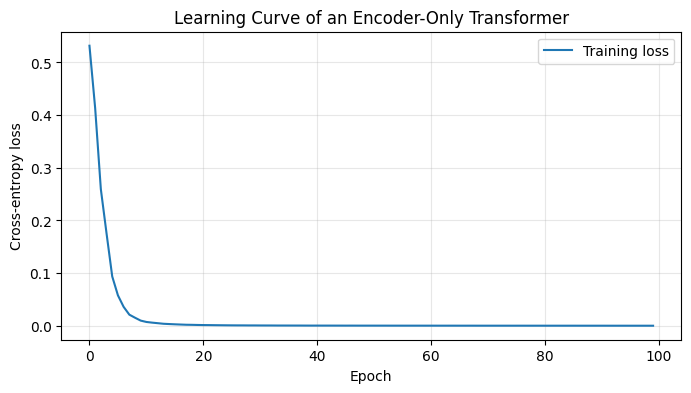

In [104]:
# This cell is self-contained, so it still works even if you run it before the import cell above.
try:
    import matplotlib.pyplot as plt
    has_matplotlib = True
except ImportError:
    plt = None
    has_matplotlib = False

if has_matplotlib:
    plt.figure(figsize=(8, 4))
    plt.plot(loss_history, label='Training loss')
    plt.xlabel('Epoch')
    plt.ylabel('Cross-entropy loss')
    plt.title('Learning Curve of an Encoder-Only Transformer')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print('matplotlib is not installed, so only the numeric loss history is shown.')

## Step 13: Simple Inference

After training, we can switch the model to evaluation mode and predict the class for new sequences.

In [105]:
# Definining inference function
#   set the model into evaluation mode
#   predict the class of new sequences
def predict_class(model, input_sequence):
    # change the model into evaluation mode..
    #   evaluation mode disables:
    #       - dropout
    model.eval()

    # torch.no_grad() means do not track operations for gradient computation
    #   saves memory and speed up inferencing as gradient computation tracking needed in training
    with torch.no_grad():
        # runs forward()
        logits = model(input_sequence)

        # The predicted class is the one with the highest logit
        #   argmax() looks across the innermost (dim=-1) dimension (num_classes)
        #   token-wise mode returns one class per token position
        predicted_class = torch.argmax(logits, dim=-1)

    return predicted_class

# Let's test it on some sequences similar to our training set
test_inputs = torch.tensor([
    [1, 2, 3, 4, 5, 6],    # Should predict 0
    [12, 13, 14, 15, 2, 3] # Should predict 1
], dtype=torch.long)

predictions = predict_class(model, test_inputs)

# listing the test_inputs as input
print('Test inputs:', test_inputs.tolist())
# listing the predicted classes
print('Predicted classes:', predictions.tolist())

Test inputs: [[1, 2, 3, 4, 5, 6], [12, 13, 14, 15, 2, 3]]
Predicted classes: [[0, 0, 0, 0, 0, 0], [1, 1, 1, 0, 0, 0]]


## Summary

- `forward()` moves data through embeddings, **bidirectional** attention, feed-forward layers, pooling, and the output layer.
- `loss.backward()` sends gradients backward through the whole encoder-only transformer.
- Repeating forward, loss, backward, and optimizer updates across epochs produces a learning curve.
- After training, the model can run inference by taking an entire sequence and outputting its predicted class.